Personal project predciting customer churn using ANNS

Phase 1 - import data base and data eda and data preprocessing 

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

load data set 

In [5]:
df = pd.read_csv(r'\Users\karam\Desktop\personal project\data\cell2celltrain.csv')
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


get the categroical collums 

In [6]:
cat_cols = [col for col in df.columns if df[col].dtype=='object']
cat_cols

['Churn',
 'ServiceArea',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'HandsetPrice',
 'MadeCallToRetentionTeam',
 'CreditRating',
 'PrizmCode',
 'Occupation',
 'MaritalStatus']

In [7]:
# get the datsets informoation 
df.info(max_cols= 200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [8]:
df.isnull().sum()

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

we have several collumns with missing data we now need to decide which collumns to drop as thier useless to us and rows to drop due to missing data and avereges to add for rows that need it -- collums like customer id are usless to us so we can drop them collums like monthyly rev, mins ,total rec charge , director assited calls ,overage minutes and roaming calls are critical data so dropping would be ideal as replacing this data could add unesscary noise in out predicition models. service area we drop as too spefic to guess , collums with small amount of missing data we drop as 1 out of 51,000 isnt particualr impactful. percchange mins and rev we will fill with 0s as missing values usally mean no change recorded / new customers and for age since thiers alot of missing data we can use median to replace it mitgating the loss of the data 

In [9]:

df = df.drop(['CustomerID'], axis=1)

df = df.dropna(subset=['MonthlyRevenue', 'MonthlyMinutes', 'ServiceArea', 'Handsets', 'CurrentEquipmentDays'])


df['PercChangeMinutes'] = df['PercChangeMinutes'].fillna(0)
df['PercChangeRevenues'] = df['PercChangeRevenues'].fillna(0)


df['AgeHH1'] = df['AgeHH1'].fillna(df['AgeHH1'].median())
df['AgeHH2'] = df['AgeHH2'].fillna(df['AgeHH2'].median())


missing_data = df.isnull().sum()
print(f"check if any missing data left :{missing_data}")
print(f"new shape {df.shape}")

check if any missing data left :Churn                        0
MonthlyRevenue               0
MonthlyMinutes               0
TotalRecurringCharge         0
DirectorAssistedCalls        0
OverageMinutes               0
RoamingCalls                 0
PercChangeMinutes            0
PercChangeRevenues           0
DroppedCalls                 0
BlockedCalls                 0
UnansweredCalls              0
CustomerCareCalls            0
ThreewayCalls                0
ReceivedCalls                0
OutboundCalls                0
InboundCalls                 0
PeakCallsInOut               0
OffPeakCallsInOut            0
DroppedBlockedCalls          0
CallForwardingCalls          0
CallWaitingCalls             0
MonthsInService              0
UniqueSubs                   0
ActiveSubs                   0
ServiceArea                  0
Handsets                     0
HandsetModels                0
CurrentEquipmentDays         0
AgeHH1                       0
AgeHH2                       0
Childre

implements graphs needed to analyse what aour colums mean for business and how they relate to churn EDA

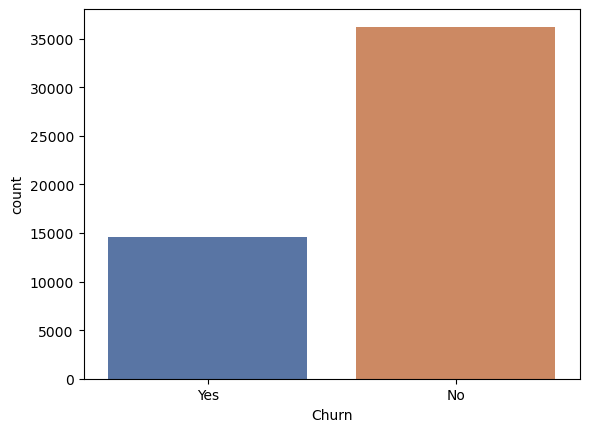

In [10]:
sns.countplot(x='Churn' , data=df ,palette = 'deep');


as we can see our data is not balanced we would need to implement some kind of balancing with sampling techniques  ie smote etc to increanse the number of yes has chruned 

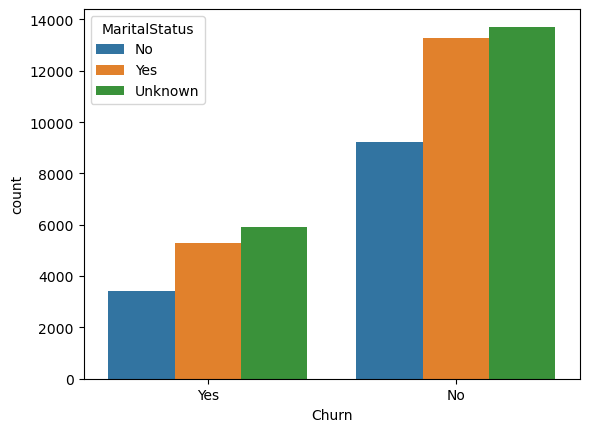

In [11]:
sns.countplot(x = 'Churn' , hue ='MaritalStatus' , data =df);


from what we can see here suprislingly thier seems to be a slighlty higher churn rate for those marriedthan not 

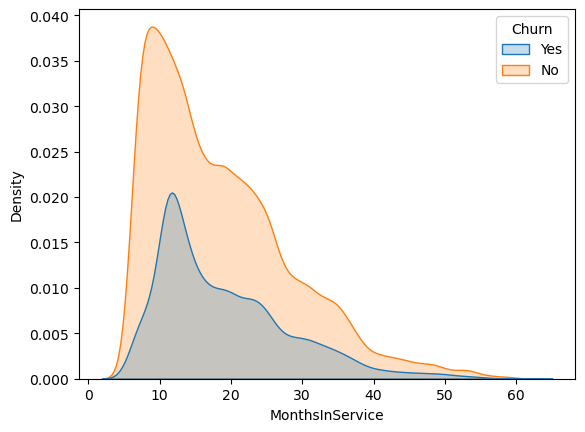

In [12]:
sns.kdeplot(x = 'MonthsInService', hue = 'Churn' , data = df , fill = True);

both churned and kept customers seem to peak at same or similar times between 9 to 15 months meaning tenure monthis in service is not the greatest 
factor in churn rate 

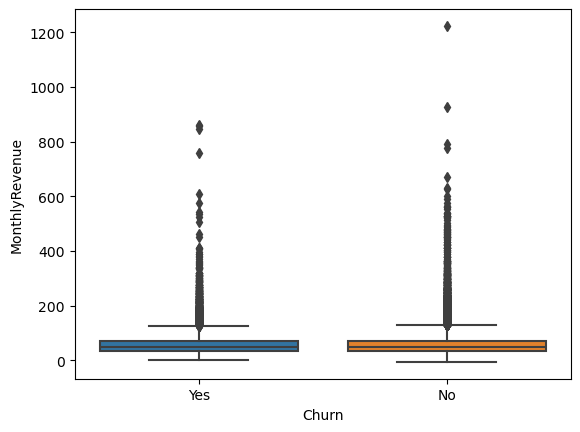

In [13]:
sns.boxplot(x='Churn', y='MonthlyRevenue', data=df);

the medians are seen to be very similar due to the signifcant number of outliers which can cause problems in our models later on it would make sense 
to do a log transformation 

finding skewed values that need to be log transfromed only collums of numeric type not object 

In [14]:
no_cols = df.select_dtypes(include=['number']).columns

skew_values = df[no_cols].skew().sort_values(ascending=False)

high_skew = skew_values[abs(skew_values) > 1]
print(high_skew)


CallForwardingCalls          91.472187
UniqueSubs                   79.720030
RoamingCalls                 57.870469
ReferralsMadeBySubscriber    36.698013
AdjustmentsToCreditRating    18.707915
ThreewayCalls                17.580554
CustomerCareCalls            14.261602
DirectorAssistedCalls        13.575428
CallWaitingCalls             11.110362
ActiveSubs                   10.686357
BlockedCalls                  9.783990
RetentionOffersAccepted       8.720900
OverageMinutes                8.114603
PercChangeRevenues            7.904543
RetentionCalls                6.291478
InboundCalls                  5.928426
DroppedBlockedCalls           5.523918
DroppedCalls                  4.551644
UnansweredCalls               4.383806
MonthlyRevenue                4.182877
OutboundCalls                 3.512506
OffPeakCallsInOut             3.488601
PeakCallsInOut                3.311603
Handsets                      3.295330
ReceivedCalls                 3.113601
HandsetModels            

of these skewed collums we will only transfrom the collums of continous varibale type as doing so to discrete type would make it harder instead of easer for our models spefically our ann

In [15]:
"""cols_to_log = [
    'MonthlyRevenue', 'MonthlyMinutes', 'OverageMinutes', 
    'RoamingCalls', 'DroppedCalls', 'BlockedCalls', 
    'CustomerCareCalls', 'PeakCallsInOut', 'OffPeakCallsInOut'
    
]
for col in cols_to_log:
    if col in df.columns:
        df[col] = np.log1p(df[col])"""

"cols_to_log = [\n    'MonthlyRevenue', 'MonthlyMinutes', 'OverageMinutes', \n    'RoamingCalls', 'DroppedCalls', 'BlockedCalls', \n    'CustomerCareCalls', 'PeakCallsInOut', 'OffPeakCallsInOut'\n    \n]\nfor col in cols_to_log:\n    if col in df.columns:\n        df[col] = np.log1p(df[col])"

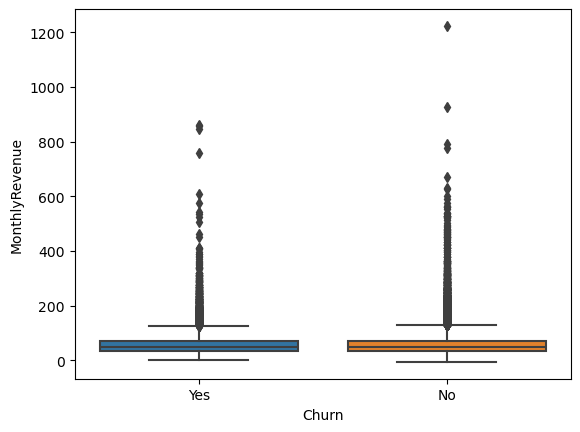

In [16]:
sns.boxplot(x='Churn', y='MonthlyRevenue', data=df);

turned into normal distrabution for our models 

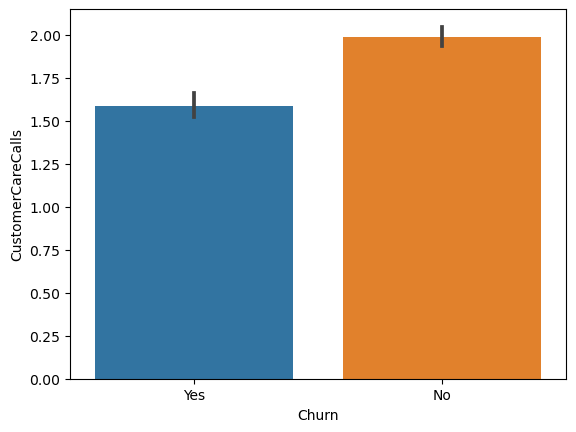

In [17]:
sns.barplot(x='Churn', y='CustomerCareCalls', data=df);

from this we can see that while a significant amount of customers stay and dont churn when asking for help a significant amount also leave with diffrence between the 2 only been 0.1 showing us that maybe the business help sevice needs to be improved 

<Axes: xlabel='Churn', ylabel='CurrentEquipmentDays'>

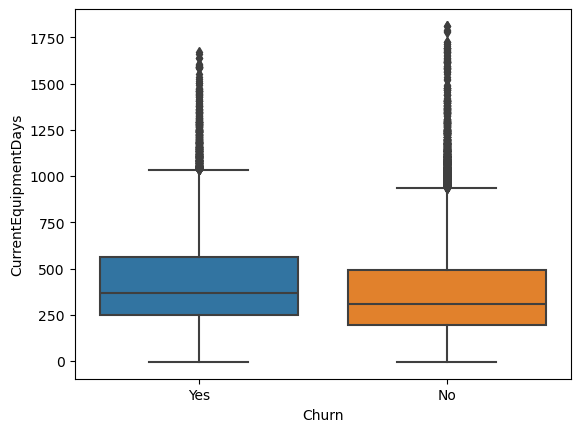

In [18]:
sns.boxplot(x='Churn', y='CurrentEquipmentDays', data=df)

from here what we can see is that on average people with on avaerge people with older phones are slighlty more likely to churn likely as to buy a new phone 

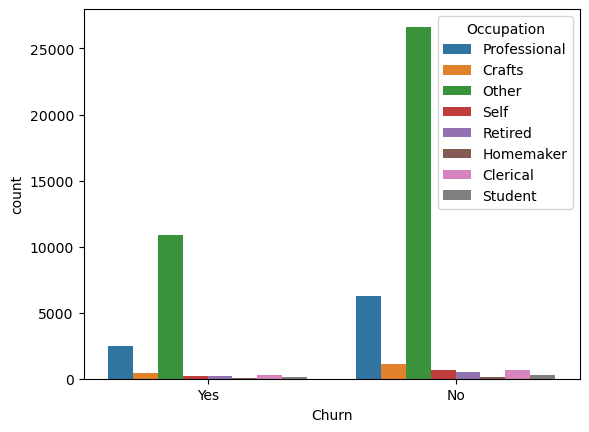

In [19]:
sns.countplot(x='Churn', hue='Occupation', data=df);

from what we can see on avaerge the churn rate of customers of diffrent occupations differ slightly where only professionals have a decently higher churn rate as well as other with the rest seemingly similar in churn rate 

now we need to turn our object data too numbers ,for object data with 2choices well use label encoding for multiply well use one hot encoding and for ones with too many choices we will just drop the collum. we drop severice area as the choices for this is endless and we identify all object data

In [20]:

df = df.drop(['ServiceArea'], axis=1)

object_cols = df.select_dtypes(include=['object']).columns
print(list(object_cols))

['Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']


will drop not new cellphone user as same results as new cellphone users and use one hot on non binary data

In [21]:
df = df.drop(['NotNewCellphoneUser'], axis=1)

dropping other irelcvant / non important collums 

In [22]:

extra_drops = [
    'DroppedBlockedCalls', 
    'UniqueSubs',        
    'HandsetModels',    
    'AgeHH2',             
    'PrizmCode'           
]
df = df.drop(columns=extra_drops)

print(f"Final feature count for modeling: {df.shape[1]}")

Final feature count for modeling: 50


checking for binary values and values with more than 2 choices 

In [23]:
multi_cols_check = ['Homeownership', 'HandsetPrice', 'CreditRating', 'Occupation', 'MaritalStatus','Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam']

for col in multi_cols_check:
    print(f"{col}: {df[col].unique()}")

Homeownership: ['Known' 'Unknown']
HandsetPrice: ['30' 'Unknown' '10' '80' '150' '300' '40' '200' '100' '130' '60' '400'
 '240' '250' '180' '500']
CreditRating: ['1-Highest' '4-Medium' '3-Good' '6-VeryLow' '2-High' '5-Low' '7-Lowest']
Occupation: ['Professional' 'Crafts' 'Other' 'Self' 'Retired' 'Homemaker' 'Clerical'
 'Student']
MaritalStatus: ['No' 'Yes' 'Unknown']
Churn: ['Yes' 'No']
ChildrenInHH: ['No' 'Yes']
HandsetRefurbished: ['No' 'Yes']
HandsetWebCapable: ['Yes' 'No']
TruckOwner: ['No' 'Yes']
RVOwner: ['No' 'Yes']
BuysViaMailOrder: ['Yes' 'No']
RespondsToMailOffers: ['Yes' 'No']
OptOutMailings: ['No' 'Yes']
NonUSTravel: ['No' 'Yes']
OwnsComputer: ['Yes' 'No']
HasCreditCard: ['Yes' 'No']
NewCellphoneUser: ['No' 'Yes']
OwnsMotorcycle: ['No' 'Yes']
MadeCallToRetentionTeam: ['Yes' 'No']


In [24]:
from sklearn.preprocessing import LabelEncoder

binary_cols = [
    'Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 
    'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 
    'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 
    'NewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'Homeownership'
]

multi_cols = ['HandsetPrice', 'CreditRating', 'Occupation', 'MaritalStatus']

lab = LabelEncoder()
for col in binary_cols:
    df[col] = lab.fit_transform(df[col])

# drop first to prebemt linear and ann from poteinally getting confused and makes data set smaller if we know 2 categroies we can work out the 3rd so ones not needed 
df = pd.get_dummies(df, columns=multi_cols, drop_first=True) 

print(f"no of collums {df.shape[1]}")

no of collums 76


In [25]:

df = df.fillna(df.mode().iloc[0])

print(f"Total NaNs remaining: {df.isnull().sum().sum()}")

Total NaNs remaining: 0


no we will make a heatmap to 1 show realtionships between collums and 2 to realtionship on what is mkaing cutomers churn

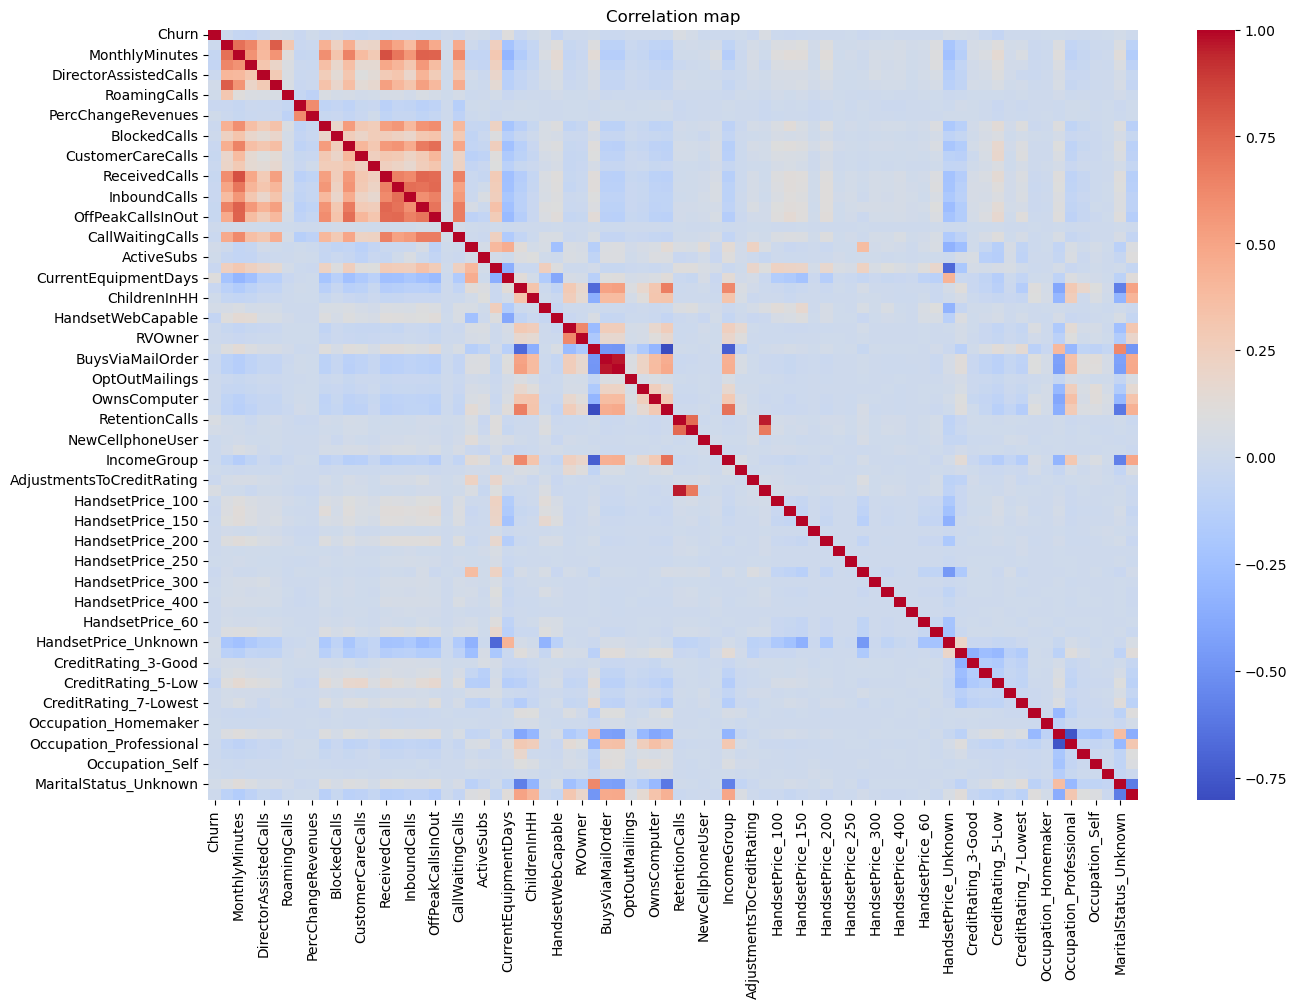

In [26]:
plt.figure(figsize=(15, 10))


sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False) 

plt.title("Correlation map")
plt.show()

this heatmap shows us how much each feature correltes with each other this can show us important infromation about our customer demogra[hic ie age hh1 has a strong corelation with cildren in home and what we then can look at is our churn heatmap showing us agehh1 has a churn rate of -0.03 meaning peole of this age range on avaerge are less likely to churn howver childreinhh has a churn rate of 0.0099 meaning that if some one in age range agehh1 has a child in household despite being less likly to churn with child they are more likely to churn

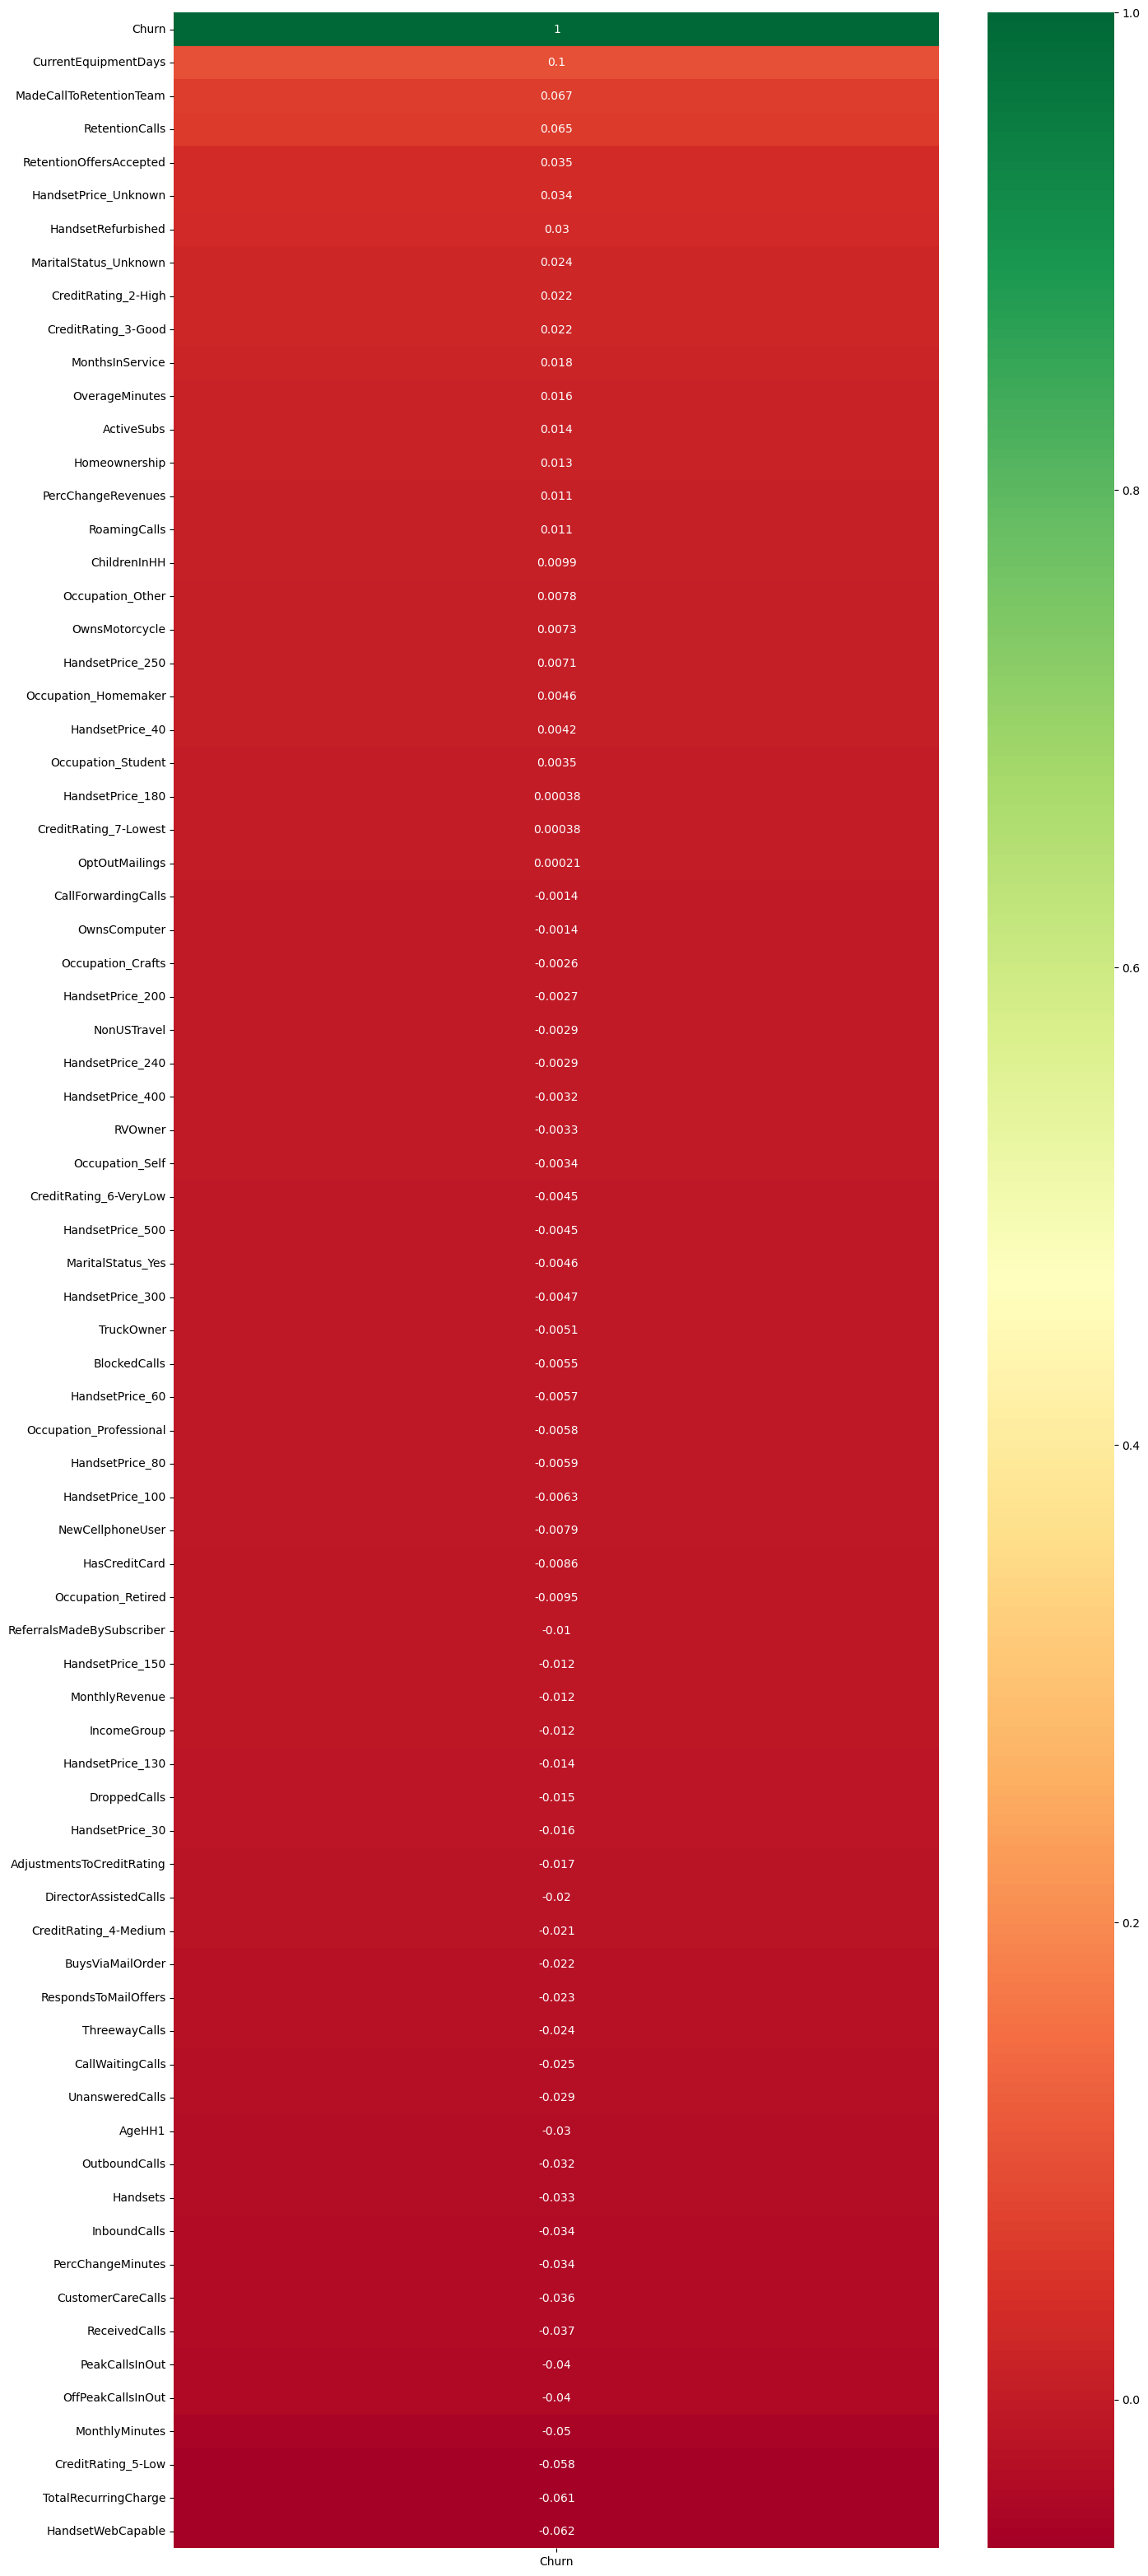

In [27]:

churn_corr = df.corr(numeric_only=True)[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(15, 40))
sns.heatmap(churn_corr, annot=True, cmap='RdYlGn')
plt.show()

this heatmap shows the correlation bewteen diffrent factors and chance of churning iethe more time someone makes call to rentetion team the more likel they are to churn and similar the more montly minutes someone has the less likely they are to churn closer to 1 more likly to churn closer to -1 less likely 

now we need to split out data into train and test and do everything we did on trsin to test ie log encoding and collums dropped 

In [28]:
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [29]:
from sklearn.model_selection import train_test_split

X_main = df.drop('Churn' , axis=1)
Y_main = df['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(X_main, Y_main, test_size=0.2, random_state=42, stratify=Y_main)



now we need to use robust scalr as for some of our model the ann and linear regression in particular will view certain features as more important due to ahveing more data which is innacurate and unfair test so we need to robust scalar

In [30]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
# robust scaler done just on train data then transfromed on test data to make it a fair test so model dosent have any prior knowledge and can cheat 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#makes sures thiers no NaNs in our data after scale sets them to zero so we can ru smote  
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)       

now we need to add smote TOMEK to balance data LOOKS OF PAIRS OF CHURNS LIKE IN OUR CORELATION MAP  and for churns and non churns very highlily coreelated it would delte them to make a clear path 

In [31]:
from imblearn.combine import SMOTETomek

smT = SMOTETomek(random_state =42)
X_train_s, Y_train_s = smT.fit_resample(X_train_scaled, Y_train)


In [32]:
from imblearn.combine import SMOTEENN

# Initialize SMOTE-ENN (The Aggressive Cleaner)
# It first oversamples the Churners, then deletes noisy points from both classes
sme = SMOTEENN(random_state=42)

# Apply to your data (You can use X_train_scaled OR X_train)
X_en_rf, Y_en_rf = sme.fit_resample(X_train_scaled, Y_train)




phase 2 baseline models linar regression, random forest and xgboost


grid search cv to find the best parametters for logistic regression 

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


"""param_dict = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.0001, 0.001, 0.01, 0.1, 10, 100]
    },
    #need to seperate them as some solvers only work with l2 not l1 
    {
        'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
        'penalty': ['l2'],
        'C': [0.0001, 0.001, 0.01, 0.1, 10, 100]
    }
]

l_grid_s = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'), 
    param_dict, 
    scoring='f1', 
    cv=5,
)

l_grid_s.fit(X_train_s, Y_train_s)

print(f"Best Parameters: {l_grid_s.best_params_}")
print(f"Best F1 Score: {l_grid_s.best_score_}")"""

'param_dict = [\n    {\n        \'solver\': [\'liblinear\'],\n        \'penalty\': [\'l1\', \'l2\'],\n        \'C\': [0.0001, 0.001, 0.01, 0.1, 10, 100]\n    },\n    #need to seperate them as some solvers only work with l2 not l1 \n    {\n        \'solver\': [\'lbfgs\', \'newton-cg\', \'newton-cholesky\'],\n        \'penalty\': [\'l2\'],\n        \'C\': [0.0001, 0.001, 0.01, 0.1, 10, 100]\n    }\n]\n\nl_grid_s = GridSearchCV(\n    LogisticRegression(max_iter=1000, class_weight=\'balanced\'), \n    param_dict, \n    scoring=\'f1\', \n    cv=5,\n)\n\nl_grid_s.fit(X_train_s, Y_train_s)\n\nprint(f"Best Parameters: {l_grid_s.best_params_}")\nprint(f"Best F1 Score: {l_grid_s.best_score_}")'

Accuracy Score  = 0.5666
Precision Score = 0.3520
Recall Score    = 0.6029
F1 Score        = 0.4445
ROC-AUC Score   = 0.6070

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.55      0.64      7248
           1       0.35      0.60      0.44      2926

    accuracy                           0.57     10174
   macro avg       0.56      0.58      0.54     10174
weighted avg       0.65      0.57      0.59     10174



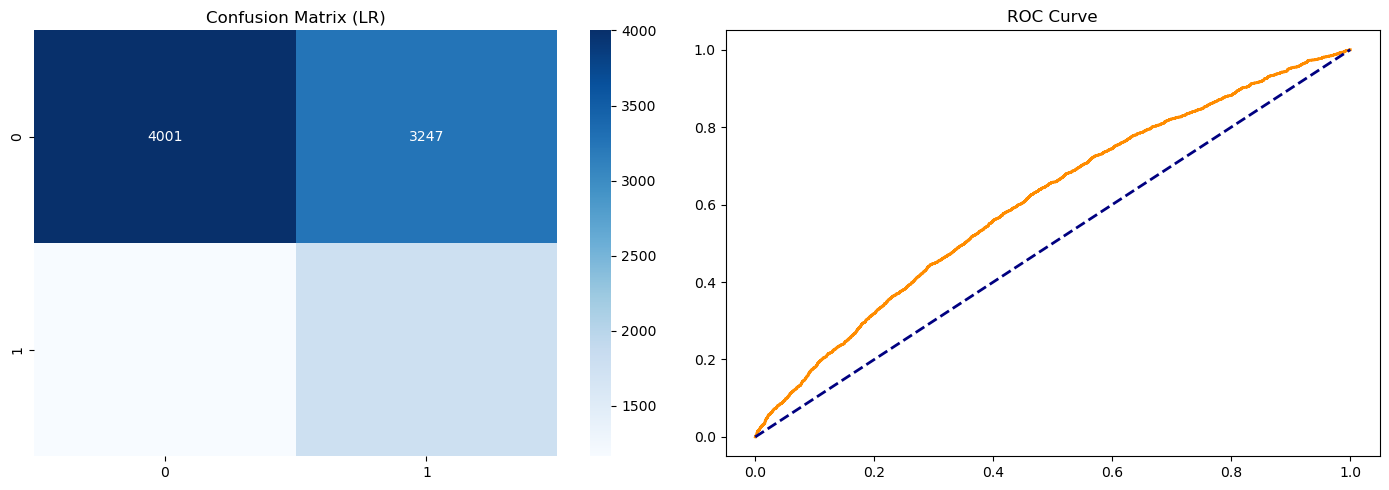

In [34]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.metrics import classification_report

l_model = LogisticRegression(
    max_iter=1000, 
    C=0.1, 
    penalty='l2', 
    solver='liblinear',
    random_state=42
)

l_model.fit(X_train_s, Y_train_s)

Y_pred_lr = l_model.predict(X_test_scaled)

l_results = [
    accuracy_score(Y_test, Y_pred_lr),
    precision_score(Y_test, Y_pred_lr),
    recall_score(Y_test, Y_pred_lr),
    f1_score(Y_test, Y_pred_lr),
    roc_auc_score(Y_test, l_model.predict_proba(X_test_scaled)[:, 1])
]

print(f"Accuracy Score  = {l_results[0]:.4f}")
print(f"Precision Score = {l_results[1]:.4f}")
print(f"Recall Score    = {l_results[2]:.4f}")
print(f"F1 Score        = {l_results[3]:.4f}")
print(f"ROC-AUC Score   = {l_results[4]:.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_lr))


fig, ax = plt.subplots(1, 2, figsize=(14, 5))


cm = confusion_matrix(Y_test, Y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix (LR)')


fpr, tpr, thresholds = roc_curve(Y_test, l_model.predict_proba(X_test_scaled)[:, 1])
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {l_results[4]:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('ROC Curve')


plt.tight_layout()
plt.show()


grid seacrch for best apram for randomforest 

In [35]:
from sklearn.ensemble import RandomForestClassifier

"""rf_dict = {
    'n_estimators': [50, 100, 300, 500],
    'max_depth': [10, 20, 30, 40, 50, 60],
    'min_samples_leaf': [2, 4, 6, 8],
    'max_features': ['sqrt', 0.5, 1], 
    'class_weight': ['balanced_subsample']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'), 
    rf_dict, 
    scoring='f1', 
    cv=3, 
    n_jobs=-1
)

rf_grid.fit(X_train_s, Y_train_s)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF F1 Score: {rf_grid.best_score_}")"""

'rf_dict = {\n    \'n_estimators\': [50, 100, 300, 500],\n    \'max_depth\': [10, 20, 30, 40, 50, 60],\n    \'min_samples_leaf\': [2, 4, 6, 8],\n    \'max_features\': [\'sqrt\', 0.5, 1], \n    \'class_weight\': [\'balanced_subsample\']\n}\n\nrf_grid = GridSearchCV(\n    RandomForestClassifier(random_state=42, class_weight=\'balanced\'), \n    rf_dict, \n    scoring=\'f1\', \n    cv=3, \n    n_jobs=-1\n)\n\nrf_grid.fit(X_train_s, Y_train_s)\n\nprint(f"Best RF Params: {rf_grid.best_params_}")\nprint(f"Best RF F1 Score: {rf_grid.best_score_}")'

RF Accuracy:  0.4377
RF Precision: 0.3239
RF Recall:    0.8787
RF F1-Score:  0.4733
ROC-AUC Score 0.6126

RF Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.26      0.40      7248
           1       0.32      0.88      0.47      2926

    accuracy                           0.44     10174
   macro avg       0.58      0.57      0.44     10174
weighted avg       0.69      0.44      0.42     10174



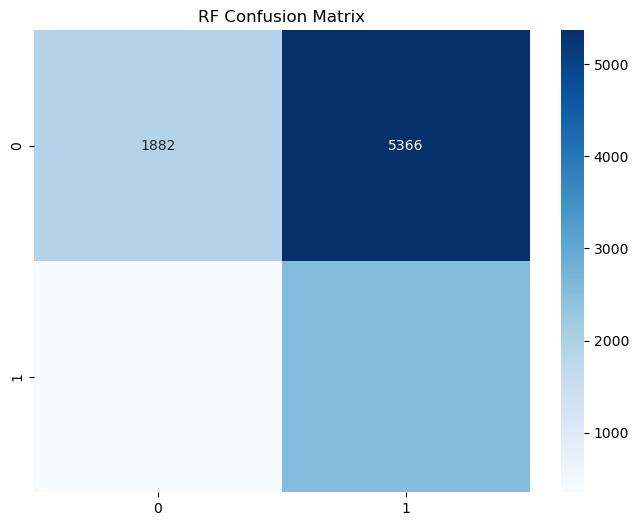

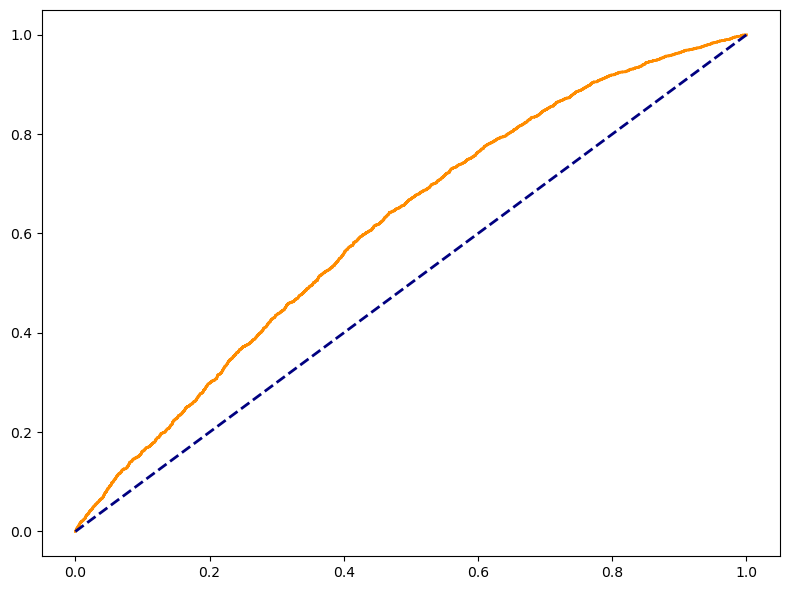

In [36]:

rf_model = RandomForestClassifier(
    n_estimators=200,     
    max_depth=None,       
    max_features=25,
    max_leaf_nodes=50,
    random_state=42,
    n_jobs=-1            
)

rf_model.fit(X_en_rf, Y_en_rf)

Y_pred_rf = rf_model.predict(X_test_scaled)
rf_results = [
    accuracy_score(Y_test, Y_pred_rf),
    precision_score(Y_test, Y_pred_rf),
    recall_score(Y_test, Y_pred_rf),
    f1_score(Y_test, Y_pred_rf),
    roc_auc_score(Y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
]

print(f"RF Accuracy:  {rf_results[0]:.4f}")
print(f"RF Precision: {rf_results[1]:.4f}")
print(f"RF Recall:    {rf_results[2]:.4f}")
print(f"RF F1-Score:  {rf_results[3]:.4f}")
print(f"ROC-AUC Score {rf_results[4]:.4f}")
print("\nRF Classification Report:")
print(classification_report(Y_test, Y_pred_rf))



plt.figure(figsize=(8, 6))
cm = confusion_matrix(Y_test, Y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('RF Confusion Matrix')
plt.show()



fpr, tpr, _ = roc_curve(Y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.tight_layout()
plt.show()

xgboost gridsearch for best param

In [37]:
#pip install xgboost

In [38]:
from xgboost import XGBClassifier
import xgboost as xgb

"""xgb_dict = {
   'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 6, 9],
    'scale_pos_weight': [1 ,2.3 ,3 , 5],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
    xgb_dict, 
    scoring='f1', 
    cv=3, 
    
)

xgb_grid.fit(X_train_s, Y_train_s)

print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB F1 Score: {xgb_grid.best_score_}")"""

'xgb_dict = {\n   \'n_estimators\': [100, 300, 500],\n    \'learning_rate\': [0.01, 0.05, 0.1], \n    \'max_depth\': [3, 6, 9],\n    \'scale_pos_weight\': [1 ,2.3 ,3 , 5],\n    \'colsample_bytree\': [0.8, 1.0],\n    \'gamma\': [0, 0.1]\n}\n\nxgb_grid = GridSearchCV(\n    XGBClassifier(use_label_encoder=False, eval_metric=\'logloss\'), \n    xgb_dict, \n    scoring=\'f1\', \n    cv=3, \n    \n)\n\nxgb_grid.fit(X_train_s, Y_train_s)\n\nprint(f"Best XGB Params: {xgb_grid.best_params_}")\nprint(f"Best XGB F1 Score: {xgb_grid.best_score_}")'

In [39]:
#focal loss implmentation best sampling tech for xg
def focal_loss (Y_label ,Y_predict):
    labels = Y_label
    #applys the transformationtion sigmoid making raw data probability 
    predict = 1.0/(1.0 + np.exp(-Y_predict))
    #hyperparameters higher gamma more focus on harder problems alpha is wieghting of lasses which is moreimportant 
    gamma = 2.0
    alpha = .80
    # workout the graident first derivative telling xgboostr how to move wieghts to reduce error
    gradient = (-alpha * labels * (1 - predict)**gamma * (1 - predict)  + (1 - alpha) * (1 - labels) * predict**gamma * predict)
    #second derivative determine the step so how big the chnages will be 
    second_d = (alpha * labels * (1 - predict)**gamma * predict * (1 - predict) + (1 - alpha) * (1 - labels) * predict**gamma * predict * (1 - predict))
    
    return gradient, second_d


XGB Accuracy:  0.5233
XGB Precision: 0.3567
XGB Recall:    0.8185
XGB F1-Score:  0.4969
XGB ROC-AUC:   0.6759

XGB Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.40      0.55      7248
           1       0.36      0.82      0.50      2926

    accuracy                           0.52     10174
   macro avg       0.60      0.61      0.52     10174
weighted avg       0.71      0.52      0.53     10174



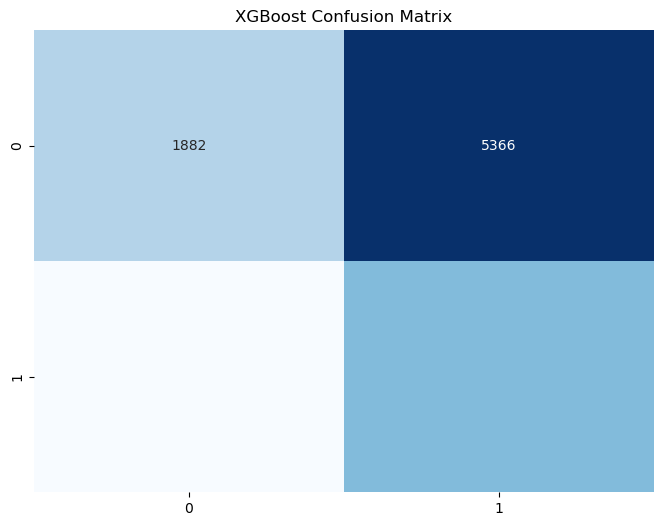

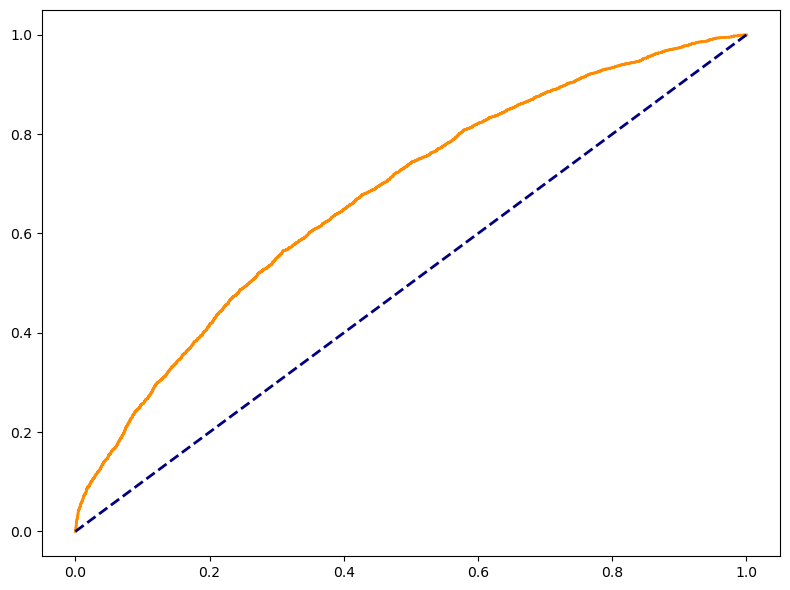

In [40]:
#xgboost implemnt with focal loss as sampling focal loss makes itso eaiser models are less importan making xgboost focus on the stuff thats harder to wget info from
xgb_focal = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    objective=focal_loss,
    tree_method='hist'
)

#use non scaled data tree dont need scaling 
xgb_focal.fit(X_train, Y_train)


raw_predict = xgb_focal.predict(X_test, output_margin=True)
probabilities = 1.0 / (1.0 + np.exp(-raw_predict)) # apply the sigmoid transfromation raw data to probaility 
final_predict = (probabilities > 0.5).astype(int) 

xgb_results = [
    accuracy_score(Y_test, final_predict),
    precision_score(Y_test, final_predict),
    recall_score(Y_test, final_predict),
    f1_score(Y_test, final_predict),
    roc_auc_score(Y_test, probabilities)
]

print(f"XGB Accuracy:  {xgb_results[0]:.4f}")
print(f"XGB Precision: {xgb_results[1]:.4f}")
print(f"XGB Recall:    {xgb_results[2]:.4f}")
print(f"XGB F1-Score:  {xgb_results[3]:.4f}")
print(f"XGB ROC-AUC:   {xgb_results[4]:.4f}")
print("\nXGB Classification Report:")
print(classification_report(Y_test, final_predict))


cm_xg = confusion_matrix(Y_test, final_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('XGBoost Confusion Matrix')
plt.show()


fpr, tpr, thresholds = roc_curve(Y_test, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.tight_layout()
plt.show()

In [41]:
#pip install tensorflow
#%pip install keras-tuner
#%pip install tensorboard


constructing the final part the ANN

In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks



def build_model(A):
    model = models.Sequential()
    
    #TEST for diffrent params for the width of the ann so we tell model if bigger more complex pattern recog
    A_units = A.Choice('units_1', values=[64, 128, 256])
    
     #Test params for dropout as data is very noise to stop model getting stuck on 1 thing
    A_dropout = A.Choice('dropout_rate', values=[0.3, 0.4, 0.5])
    
    # first layer  small wieght to stop single feature domination 
    model.add(layers.Dense(units=A_units, input_shape=(X_train_s.shape[1],), kernel_regularizer=regularizers.l2(0.001)))
    # batch norm to normalise input after wieght chnage and speed things up 
    model.add(layers.BatchNormalization()) 
    #allow small negatives to stop dead neurons 
    model.add(layers.LeakyReLU(alpha=0.1)) 
    #to prevent the impact of noise and stop anns from memorising noiser 
    model.add(layers.Dropout(A_dropout))
    
    # second layer half the units of the first layer to compress features and stop overfitting
    model.add(layers.Dense(units=A_units // 2, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(A_dropout - 0.1))
    
    # output layer with sigmoid to get probability of churn
    model.add(layers.Dense(1, activation='sigmoid'))
    
    #param 3 test for learning rate to control how much the model updates its weights each step
    A_learning_rate = A.Choice('learning_rate', values=[1e-3, 5e-4])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=A_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['auc'])
    return model

# grid search setup 
tuner = kt.GridSearch(
    build_model,
    objective=kt.Objective("auc", direction="max"),
    max_trials=18, 
    project_name='personal proj ann',
    overwrite=True
)

#run the search 
tuner.search(X_train_s, Y_train_s, epochs=20, validation_split=0.2, verbose=1)


best_A = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Neurons: {best_A.get('units_1')}, Best Dropout: {best_A.get('dropout_rate')}, Best Learning Rate: {best_A.get('learning_rate')}")

Trial 18 Complete [00h 00m 40s]
auc: 0.6275241374969482

Best auc So Far: 0.6438502669334412
Total elapsed time: 00h 10m 40s
Best Neurons: 128, Best Dropout: 0.3


Epoch 1/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - auc: 0.5709 - loss: 0.8144 - val_auc: 0.6005 - val_loss: 0.7607 - learning_rate: 5.0000e-04
Epoch 2/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - auc: 0.6089 - loss: 0.7339 - val_auc: 0.6084 - val_loss: 0.7222 - learning_rate: 5.0000e-04
Epoch 3/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - auc: 0.6207 - loss: 0.7022 - val_auc: 0.6131 - val_loss: 0.6942 - learning_rate: 5.0000e-04
Epoch 4/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - auc: 0.6336 - loss: 0.6844 - val_auc: 0.6156 - val_loss: 0.6969 - learning_rate: 5.0000e-04
Epoch 5/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - auc: 0.6384 - loss: 0.6765 - val_auc: 0.6196 - val_loss: 0.6724 - learning_rate: 5.0000e-04
Epoch 6/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - auc: 0.6414 - loss: 0.6728 - val_auc: 0.6180 - val_loss: 0.6860 - learning_rate: 5.0000e-04
Epoch 7/150
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - auc: 0.6464 - loss: 0.6697 - val_auc: 0.6179 - 

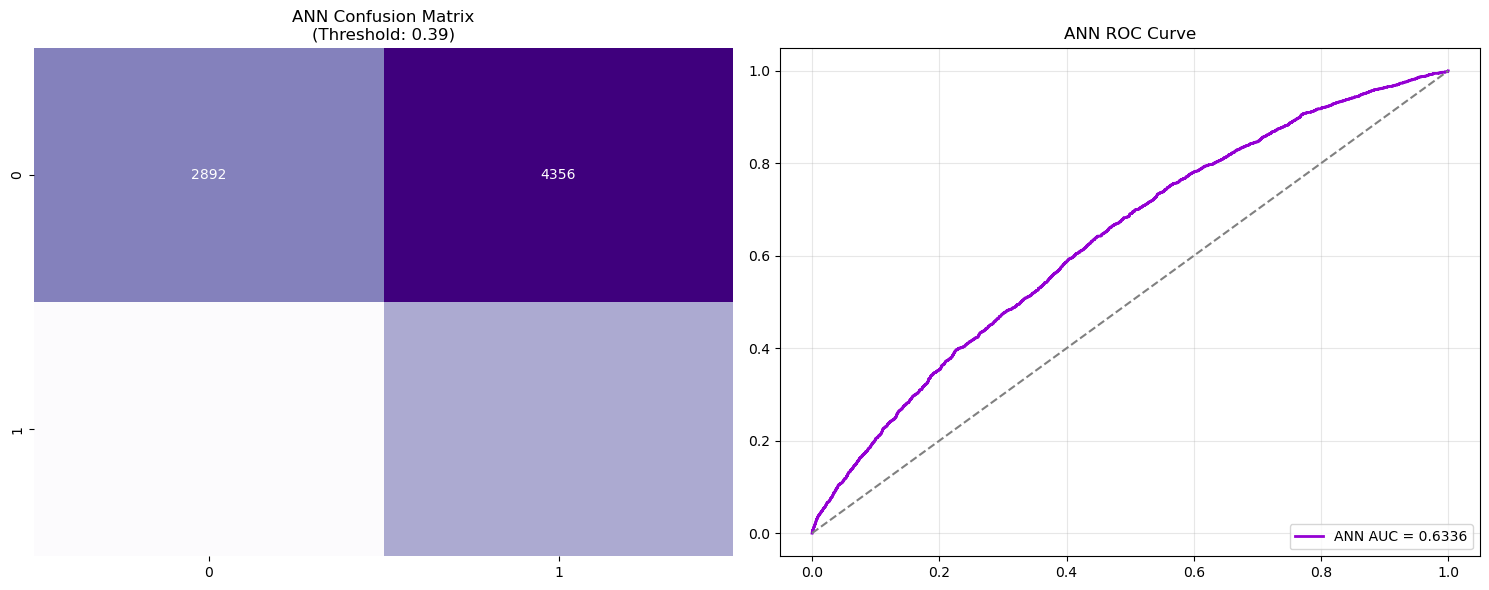

In [49]:
ANN = tuner.hypermodel.build(best_A)

#callbacks early stop if no improvemt after 12 runs and reduce learning rate to prevemt model getting stuck 
callback_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)
]

#fit the model  we cross check on test to see hot it peforms on real data 
ANN_model = ANN.fit(
    X_train_s, Y_train_s,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_scaled, Y_test), 
    callbacks=callback_list,
    verbose=1
)

# Predict probabilities
ann_probs = ANN.predict(X_test_scaled).flatten()


best_t, max_f1 = 0.5, 0
for t in np.arange(0.2, 0.8, 0.01):
    f1 = f1_score(Y_test, (ann_probs > t).astype(int))
    if f1 > max_f1:
        max_f1, best_t = f1, t

ann_final_preds = (ann_probs > best_t).astype(int)




print(f"Accuracy:  {accuracy_score(Y_test, ann_final_preds):.4f}")
print(f"Precision: {precision_score(Y_test, ann_final_preds):.4f}")
print(f"Recall:    {recall_score(Y_test, ann_final_preds):.4f}")
print(f"F1-Score:  {f1_score(Y_test, ann_final_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(Y_test, ann_probs):.4f}")
print(classification_report(Y_test, ann_final_preds))


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
cm = confusion_matrix(Y_test, ann_final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title(f'ANN Confusion Matrix\n(Threshold: {best_t:.2f})')


plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(Y_test, ann_probs)
roc_auc_val = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'ANN AUC = {roc_auc_val:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ANN ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Feature importance now that we have our modesl running with thier score we will now check what they viewed as most important in comarsion to each other 

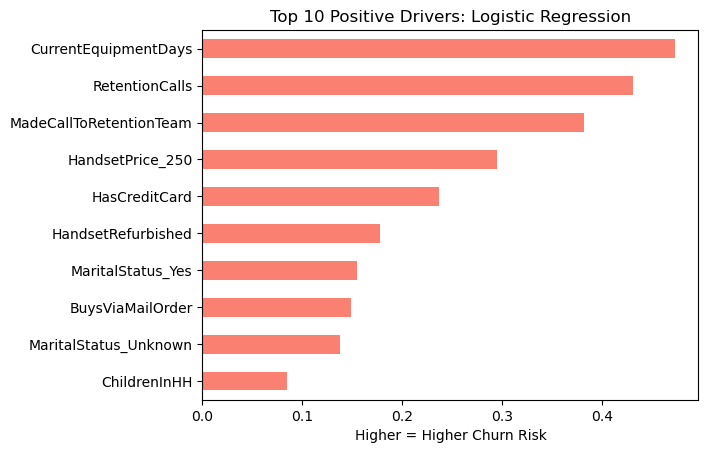

In [55]:
feature_names = df.drop('Churn', axis=1).columns
log_importance = pd.Series(l_model.coef_[0], index=feature_names)
log_importance.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Positive Drivers: Logistic Regression')
plt.xlabel('Higher = Higher Churn Risk')
plt.gca().invert_yaxis()
plt.show()

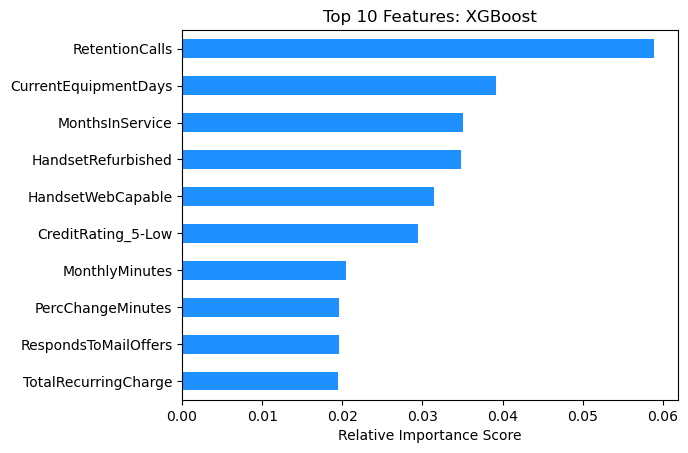

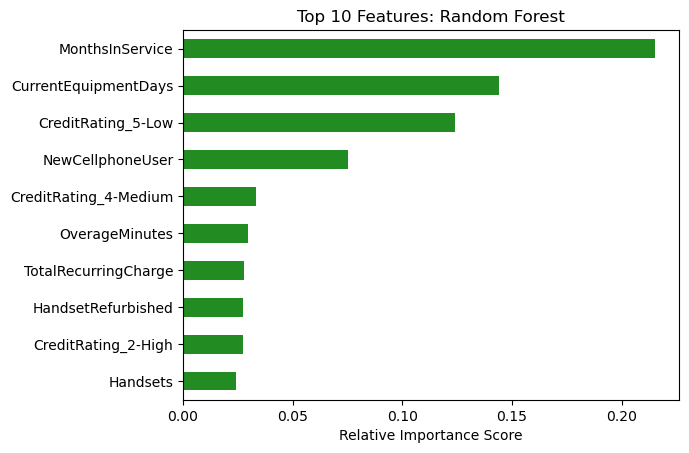

In [ ]:

def plot_tree_importance(model, model_name, color):
  
    feat_importances = pd.Series(model.feature_importances_, index=feature_names)
    feat_importances.nlargest(10).plot(kind='barh', color=color)
    plt.title(f'Top 10 Features: {model_name}')
    plt.xlabel('Relative Importance Score')
    plt.gca().invert_yaxis()
    plt.show()


plot_tree_importance(xgb_focal, "XGBoost", 'dodgerblue')
plot_tree_importance(rf_model, "Random Forest", 'forestgreen')

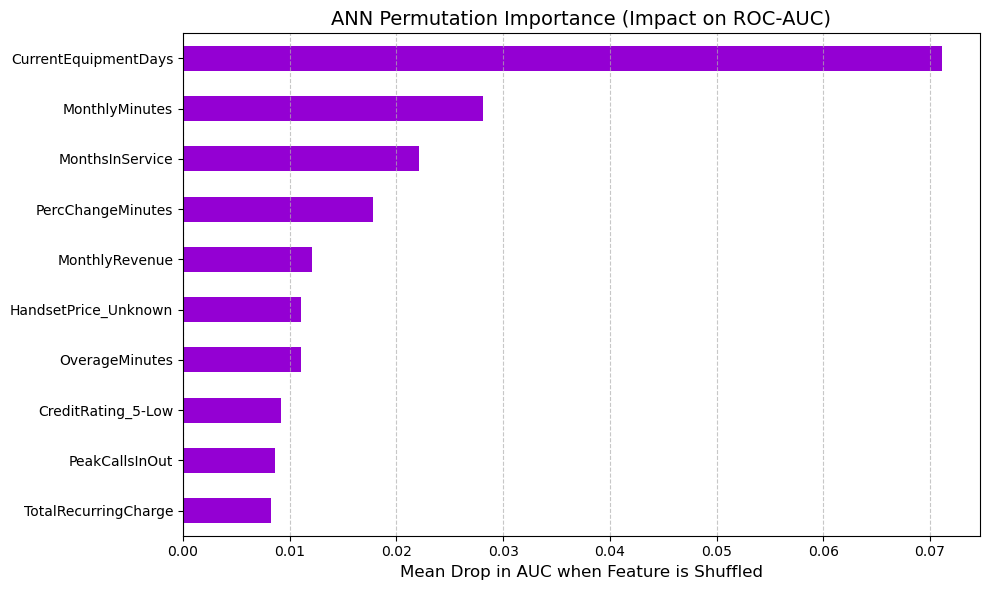

In [ ]:
from sklearn.inspection import permutation_importance



def ann_auc_scorer(estimator, X, y):

    probs = estimator.predict(X, verbose=0).flatten()
    return roc_auc_score(y, probs)


result = permutation_importance(
    ANN,            
    X_test_scaled, 
    Y_test, 
    scoring=ann_auc_scorer, 
    n_repeats=3,      
    random_state=42
)


ann_importance = pd.Series(result.importances_mean, index=feature_names)

plt.figure(figsize=(10, 6))
ann_importance.nlargest(10).plot(kind='barh', color='darkviolet')
plt.title('ANN Permutation Importance (Impact on ROC-AUC)', fontsize=14)
plt.xlabel('Mean Drop in AUC when Feature is Shuffled', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
